# Powder Particle Size Characterization

This notebook analyzes a sample metal powder particle size distribution for powder metallurgy and additive manufacturing applications.

The analysis includes:
- basic particle size statistics
- D10, D50, and D90 values
- span calculation
- histogram visualization
- cumulative particle size distribution curve

In [1]:
print("Powder Particle Size Analyzer")

Powder Particle Size Analyzer


In [2]:
import pandas as pd
import matplotlib.pyplot as plt

# Example powder particle size data in micrometers
data = {
    "diameter_um": [
        12, 15, 18, 20, 22, 25, 28, 30, 32, 35,
        38, 40, 42, 45, 48, 50, 55, 60, 65, 70
    ]
}

df = pd.DataFrame(data)

df

,diameter_um
0,12
1,15
2,18
3,20
4,22
5,25
6,28
7,30
8,32
9,35


## Particle Size Distribution Parameters

D10, D50, and D90 are common powder characterization values.

- D10: 10% of particles are smaller than this size
- D50: median particle size
- D90: 90% of particles are smaller than this size

The span value describes the width of the particle size distribution.

In [3]:
sizes = df["diameter_um"]

mean_size = sizes.mean()
min_size = sizes.min()
max_size = sizes.max()

D10 = sizes.quantile(0.10)
D50 = sizes.quantile(0.50)
D90 = sizes.quantile(0.90)

span = (D90 - D10) / D50

print("Powder Particle Size Results")
print("----------------------------")
print(f"Mean size: {mean_size:.2f} µm")
print(f"Minimum size: {min_size:.2f} µm")
print(f"Maximum size: {max_size:.2f} µm")
print(f"D10: {D10:.2f} µm")
print(f"D50: {D50:.2f} µm")
print(f"D90: {D90:.2f} µm")
print(f"Span: {span:.2f}")

Powder Particle Size Results
----------------------------
Mean size: 37.50 µm
Minimum size: 12.00 µm
Maximum size: 70.00 µm
D10: 17.70 µm
D50: 36.50 µm
D90: 60.50 µm
Span: 1.17


## Visualization

The histogram shows the frequency of particle sizes.

The cumulative distribution curve shows the percentage of particles below a given diameter.

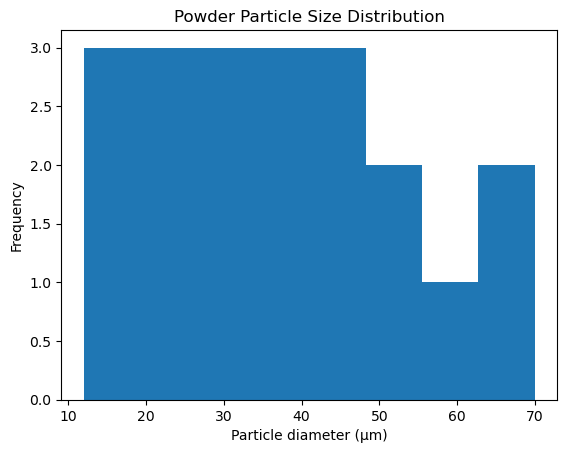

In [4]:
plt.hist(sizes, bins=8)
plt.xlabel("Particle diameter (µm)")
plt.ylabel("Frequency")
plt.title("Powder Particle Size Distribution")
plt.show()

In [5]:
if D50 < 20:
    print("Very fine powder")
elif D50 < 50:
    print("Suitable range for many LPBF applications")
else:
    print("Coarse powder distribution")

Suitable range for many LPBF applications


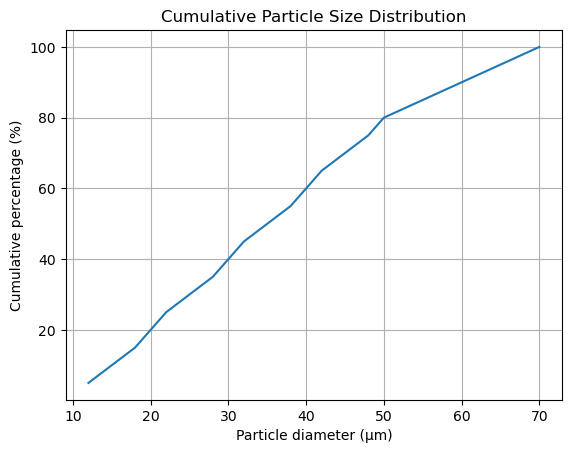

In [6]:
sorted_sizes = sizes.sort_values().reset_index(drop=True)

cumulative_percent = []

for i in range(len(sorted_sizes)):
    cumulative_percent.append((i + 1) / len(sorted_sizes) * 100)

plt.plot(sorted_sizes, cumulative_percent)

plt.xlabel("Particle diameter (µm)")
plt.ylabel("Cumulative percentage (%)")
plt.title("Cumulative Particle Size Distribution")

plt.grid(True)

plt.show()

## Conclusion

The example powder has a D50 value in a range that can be relevant for Laser Powder Bed Fusion applications. The span value gives a simple indication of the distribution width. This notebook can be expanded later by importing real CSV data, comparing powder batches, and adding powder quality scoring.